In [1]:

pip install scipy==1.15.3

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install scikit-learn

In [3]:
import statsmodels.api as sm
from sklearn.utils import resample
from scipy.stats import shapiro, mannwhitneyu
import pandas as pd

In [4]:
import statsmodels.api as sm
from sklearn.utils import resample
from scipy.stats import shapiro, mannwhitneyu

In [5]:
# Load datasets
match_data = pd.read_csv('https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/IPL/match_data.csv', low_memory=False)
match_info_data = pd.read_csv('https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/IPL/match_info_data.csv')

In [6]:
match_data.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,cricsheet_id
0,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.1,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353
1,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.2,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353
2,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.3,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353
3,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.4,Gujarat Titans,Chennai Super Kings,Shubman Gill,WP Saha,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353
4,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.5,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353


In [7]:
match_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243817 entries, 0 to 243816
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                243817 non-null  int64  
 1   season                  243817 non-null  object 
 2   start_date              243817 non-null  object 
 3   venue                   243817 non-null  object 
 4   innings                 243817 non-null  int64  
 5   ball                    243817 non-null  float64
 6   batting_team            243817 non-null  object 
 7   bowling_team            243817 non-null  object 
 8   striker                 243817 non-null  object 
 9   non_striker             243817 non-null  object 
 10  bowler                  243817 non-null  object 
 11  runs_off_bat            243817 non-null  int64  
 12  extras                  243817 non-null  int64  
 13  wides                   7652 non-null    float64
 14  noballs             

In [8]:
match_info_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1024 non-null   int64 
 1   season           1024 non-null   object
 2   city             973 non-null    object
 3   date             1024 non-null   object
 4   team1            1024 non-null   object
 5   team2            1024 non-null   object
 6   toss_winner      1024 non-null   object
 7   toss_decision    1024 non-null   object
 8   result           1024 non-null   object
 9   dl_applied       1024 non-null   int64 
 10  winner           1005 non-null   object
 11  win_by_runs      1024 non-null   int64 
 12  win_by_wickets   1024 non-null   int64 
 13  player_of_match  1019 non-null   object
 14  venue            1024 non-null   object
 15  umpire1          1024 non-null   object
 16  umpire2          1024 non-null   object
 17  umpire3          1021 non-null   

In [9]:
match_info_data.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1370353,2023,Ahmedabad,2023/05/29,Gujarat Titans,Chennai Super Kings,Chennai Super Kings,field,D/L,1,Chennai Super Kings,0,5,DP Conway,"Narendra Modi Stadium, Ahmedabad",Nitin Menon,RJ Tucker,KN Ananthapadmanabhan
1,1370352,2023,Ahmedabad,2023/05/26,Gujarat Titans,Mumbai Indians,Mumbai Indians,field,normal,0,Gujarat Titans,62,0,Shubman Gill,"Narendra Modi Stadium, Ahmedabad",Nitin Menon,RJ Tucker,J Madanagopal
2,1370351,2023,Chennai,2023/05/24,Mumbai Indians,Lucknow Super Giants,Mumbai Indians,bat,normal,0,Mumbai Indians,81,0,Akash Madhwal,"MA Chidambaram Stadium, Chepauk, Chennai",BNJ Oxenford,VK Sharma,CB Gaffaney
3,1370350,2023,Chennai,2023/05/23,Chennai Super Kings,Gujarat Titans,Gujarat Titans,field,normal,0,Chennai Super Kings,15,0,RD Gaikwad,"MA Chidambaram Stadium, Chepauk, Chennai",AK Chaudhary,CB Gaffaney,BNJ Oxenford
4,1359543,2023,Mumbai,2023/05/21,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,8,C Green,"Wankhede Stadium, Mumbai",KN Ananthapadmanabhan,RJ Tucker,R Pandit


In [10]:
# Enhanced Data Cleaning & Feature Engineering
match_info_data['date'] = pd.to_datetime(match_info_data['date'], errors='coerce')
team_runs_per_match = match_data.groupby(['match_id', 'batting_team'])['runs_off_bat'].sum().reset_index()
team_runs_per_match.rename(columns={'runs_off_bat': 'total_runs'}, inplace=True)
merged = pd.merge(team_runs_per_match, match_info_data[['id', 'date', 'venue', 'team1', 'team2']], left_on='match_id', right_on='id')
merged.drop(columns=['id'], inplace=True)
merged['Period'] = merged['date'].dt.year.apply(lambda x: 'Pre' if x < 2018 else 'Post')
merged['run_rate'] = merged['total_runs']/ 20.0
merged['year'] = merged['date'].dt.year

In [11]:
team_runs_per_match.head()

,match_id,batting_team,total_runs
0,335982,Kolkata Knight Riders,205
1,335982,Royal Challengers Bangalore,63
2,335983,Chennai Super Kings,234
3,335983,Kings XI Punjab,196
4,335984,Delhi Daredevils,122


In [12]:
    merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   match_id      2045 non-null   int64         
 1   batting_team  2045 non-null   object        
 2   total_runs    2045 non-null   int64         
 3   date          2045 non-null   datetime64[ns]
 4   venue         2045 non-null   object        
 5   team1         2045 non-null   object        
 6   team2         2045 non-null   object        
 7   Period        2045 non-null   object        
 8   run_rate      2045 non-null   float64       
 9   year          2045 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(5)
memory usage: 151.9+ KB


In [13]:
# Normality Test
pre_scores = merged[merged['Period'] == 'Pre']['total_runs']
post_scores = merged[merged['Period'] == 'Post']['total_runs']
pre_normality = shapiro(pre_scores.sample(n=500, random_state=1) if len(pre_scores) > 500 else pre_scores)
post_normality = shapiro(post_scores.sample(n=500, random_state=1) if len(post_scores) > 500 else post_scores)
print("Shapiro-Wilk Test(Pre): ", pre_normality)
print("Shapiro-Wilk Test(Post): ", post_normality)

Shapiro-Wilk Test(Pre):  ShapiroResult(statistic=np.float64(0.988417764270504), pvalue=np.float64(0.0005392374071367837))
Shapiro-Wilk Test(Post):  ShapiroResult(statistic=np.float64(0.9845150224718922), pvalue=np.float64(3.6348381261299446e-05))


In [14]:
# Match type indicator (heuristic for playoffs)
match_counts = match_info_data.groupby(match_info_data['date'].dt.year)['id'].nunique().reset_index()
match_counts.columns = ['season', 'match_count']
match_info_data['season'] = match_info_data['date'].dt.year
match_info_data['match_number'] = match_info_data.groupby('season')['date'].rank(method='first', ascending=True)
match_counts.set_index('season', inplace=True)
match_info_data['match_count'] = match_info_data['season'].map(match_counts['match_count'])
match_info_data['is_playoff'] = match_info_data['match_number'] > (match_info_data['match_count'] - 4)
merged = pd.merge(merged, match_info_data[['id', 'is_playoff']], left_on='match_id', right_on='id')
merged.drop(columns=['id'], inplace=True)

In [15]:
merged.head()

,match_id,batting_team,total_runs,date,venue,team1,team2,Period,run_rate,year,is_playoff
0,335982,Kolkata Knight Riders,205,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Pre,10.25,2008,False
1,335982,Royal Challengers Bangalore,63,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Pre,3.15,2008,False
2,335983,Chennai Super Kings,234,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Pre,11.70,2008,False
3,335983,Kings XI Punjab,196,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Pre,9.80,2008,False
4,335984,Delhi Daredevils,122,2008-04-19,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Pre,6.10,2008,False


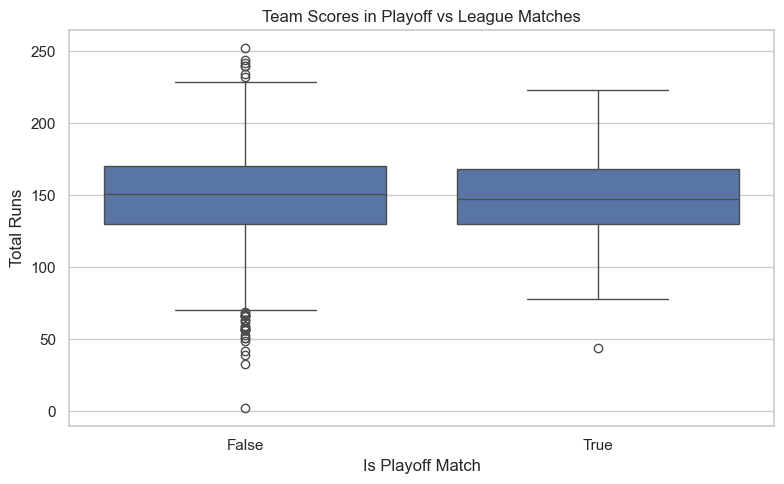

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# 1. Average Runs in Playoffs vs League Matches
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged, x='is_playoff', y='total_runs')
plt.title("Team Scores in Playoff vs League Matches")
plt.xlabel("Is Playoff Match")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

In [17]:
from scipy.stats import shapiro, mannwhitneyu

In [18]:
# Separate scores into two groups based on is_playoff flag
league_scores = merged[merged['is_playoff'] == False]['total_runs']
playoff_scores = merged[merged['is_playoff'] == True]['total_runs']

# Run the Mann-Whitney U Test 
u_statistic, p_value = mannwhitneyu(league_scores, playoff_scores, alternative='two-sided')

# Display results
print(f"Mann-Whitney U Statistic: {u_statistic}")
print(f"P-value: {p_value}")
# Interpret the result
if p_value < 0.05:
    print("✅ The difference in scores between playoffs and league matches is statistically significant.")

else:
    print("❌ No statistically significant difference in scores between playoffs and league matches.")

Mann-Whitney U Statistic: 124606.0
P-value: 0.7668706992141119
❌ No statistically significant difference in scores between playoffs and league matches.


In [19]:
# Choose your team
team_name = "Chennai Super Kings"

# Filter only this team's matches
team_data = merged[merged['batting_team'] == team_name]

# separate scores by match type
league_scores = team_data[team_data['is_playoff'] == False]['total_runs']
playoff_scores = team_data[team_data['is_playoff'] == True]['total_runs']

# Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(league_scores, playoff_scores, alternative='two-sided')
# Print Results
print(f"Team: {team_name}")
print(f"Mann-Whitney U Statistic: {u_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("✅ This team shows a statistically significant scoring difference in playoffs vs league matches.")

else:
    print("❌ No statistically significant scoring difference for this team.")

Team: Chennai Super Kings
Mann-Whitney U Statistic: 2261.0
P-value: 0.3326928611823903
❌ No statistically significant scoring difference for this team.


In [20]:
# Choose your team
team_name = "Kolkata Knight Riders"

# Filter only this team's matches
team_data = merged[merged['batting_team'] == team_name]

# separate scores by match type
league_scores = team_data[team_data['is_playoff'] == False]['total_runs']
playoff_scores = team_data[team_data['is_playoff'] == True]['total_runs']

# Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(league_scores, playoff_scores, alternative='two-sided')
# Print Results
print(f"Team: {team_name}")
print(f"Mann-Whitney U Statistic: {u_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("✅ This team shows a statistically significant scoring difference in playoffs vs league matches.")

else:
    print("❌ No statistically significant scoring difference for this team.")

Team: Kolkata Knight Riders
Mann-Whitney U Statistic: 1511.0
P-value: 0.8205743959432932
❌ No statistically significant scoring difference for this team.


In [21]:
teams = merged['batting_team'].unique()

for team in teams:
    team_data = merged[merged['batting_team'] == team]
    league_scores = team_data[team_data['is_playoff'] == False]['total_runs']
    playoff_scores = team_data[team_data['is_playoff'] == True]['total_runs']

    if len(playoff_scores) >= 3 and len(league_scores) >= 3:  # Avoid Tiny Samples
        u_stat, p_val = mannwhitneyu(league_scores, playoff_scores, alternative='two-sided')
        print(f"{team}: p = {p_val:.4f} {'✅' if p_val < 0.05 else '❌'}")

Kolkata Knight Riders: p = 0.8206 ❌
Royal Challengers Bangalore: p = 0.4337 ❌
Chennai Super Kings: p = 0.3327 ❌
Kings XI Punjab: p = 0.6591 ❌
Delhi Daredevils: p = 0.0892 ❌
Rajasthan Royals: p = 0.8971 ❌
Mumbai Indians: p = 0.4349 ❌
Deccan Chargers: p = 0.0997 ❌
Sunrisers Hyderabad: p = 0.7162 ❌
Delhi Capitals: p = 0.9859 ❌
Gujarat Titans: p = 0.4976 ❌


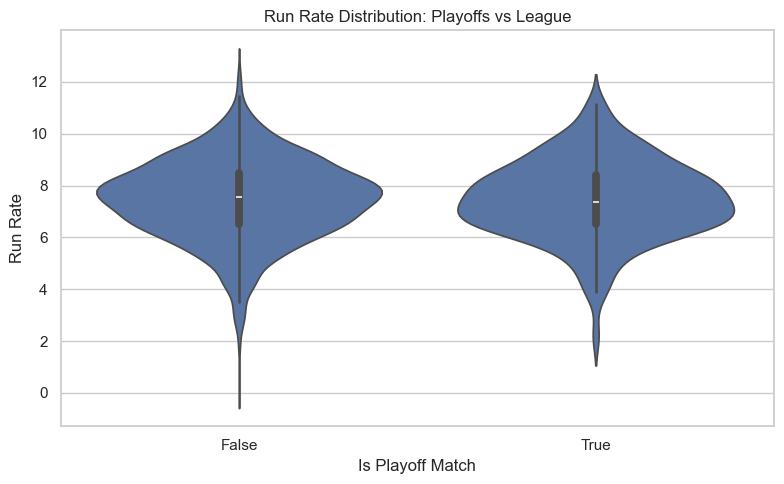

In [22]:
# Run Rate Trends in Playoff vs League Matches
plt.figure(figsize=(8,5))
sns.violinplot(data=merged, x='is_playoff', y='run_rate')
plt.title("Run Rate Distribution: Playoffs vs League")
plt.xlabel("Is Playoff Match")
plt.ylabel("Run Rate")
plt.tight_layout()
plt.show()

In [23]:
#Step 2: Split the run rate data based on is playoff
league_run_rates = merged[merged['is_playoff'] == False]['run_rate']
playoff_run_rates = merged[merged['is_playoff'] == True]['run_rate']

#Step 3: Hin the Mann-Whitney test
u_statistic, p_value = mannwhitneyu(league_run_rates, playoff_run_rates, alternative='two-sided')

#Step 4: Print the results
print(f"Mann-Whitney U Statistic: {u_statistic}")
print (f"P value: {p_value}")

#Step 5: Interpret the result
if p_value < 0.05:
    print("✅ The difference in run rates between playoffs and league matches is statistically significant.")
else:
    print("❌ No statistically significant difference in run rates between playoffs and league matches.")

Mann-Whitney U Statistic: 124606.0
P value: 0.7668706992141119
❌ No statistically significant difference in run rates between playoffs and league matches.


In [24]:
# Create an empty list to store results
results = []

# Loop through each unique team
teams = merged['batting_team'].unique()

for team in teams:
    # Filter data for this team
    team_data = merged[merged['batting_team'] == team]
#Separate run rates by match type
    league_run_rates = team_data[team_data['is_playoff'] == False]['run_rate']
    playoff_run_rates = team_data[team_data['is_playoff'] == True]['run_rate']

    # Ensure enough data points in each group to make a fair comparision
    if len(league_run_rates) >= 3 and len(playoff_run_rates) >= 3:
        #Perform the Mann-Whitney U test
        u_stat, p_val = mannwhitneyu(league_run_rates, playoff_run_rates, alternative='two-sided')

# Append the results
        results.append({
            'Team': team,
            'p-value': round(p_val, 4),
            'Significant': '✅' if p_val < 0.05 else '❌'
        })

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

                           Team  p-value Significant
0         Kolkata Knight Riders   0.8206           ❌
1   Royal Challengers Bangalore   0.4337           ❌
2           Chennai Super Kings   0.3327           ❌
3               Kings XI Punjab   0.6591           ❌
4              Delhi Daredevils   0.0892           ❌
5              Rajasthan Royals   0.8971           ❌
6                Mumbai Indians   0.4349           ❌
7               Deccan Chargers   0.0997           ❌
8           Sunrisers Hyderabad   0.7162           ❌
9                Delhi Capitals   0.9859           ❌
10               Gujarat Titans   0.4976           ❌


In [25]:
# Home vs Away flags
merged['home_team'] = merged['batting_team'] == merged['team1']
merged['away_team'] = merged['batting_team'] == merged['team2']

In [26]:
merged['home_team'].head()

0    False
1     True
2    False
3     True
4     True
Name: home_team, dtype: bool

In [27]:
# Average Runs for Home vs Away
# Melt the dataset to reshape for home vs away comparision
home_away_df = merged.melt(id_vars=['total_runs'], value_vars=['home_team', 'away_team'],
                           var_name='location', value_name='is true')

In [28]:
home_away_df.head()

,total_runs,location,is true
0,205,home_team,False
1,63,home_team,True
2,234,home_team,False
3,196,home_team,True
4,122,home_team,True


In [29]:
# Filter for only rows where the condition (home/away)
home_away_df = home_away_df[home_away_df['is true']]

In [30]:
home_away_df

,total_runs,location,is true
1,63,home_team,True
3,196,home_team,True
4,122,home_team,True
6,154,home_team,True
9,84,home_team,True
...,...,...,...
4080,179,away_team,True
4083,142,away_team,True
4084,91,away_team,True
4087,164,away_team,True


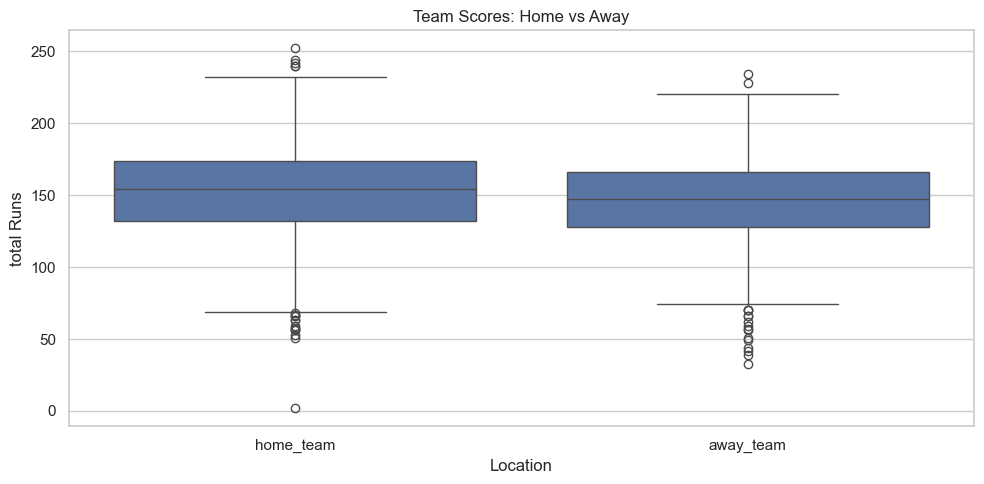

In [31]:
# Visualization
plt.figure(figsize=(10,5))
sns.boxplot(data=home_away_df, x='location', y='total_runs')
plt.title("Team Scores: Home vs Away")
plt.xlabel("Location")
plt.ylabel("total Runs")
plt.tight_layout()
plt.show()